# SMOTE and the decision threshold

Code repository for the book:

[Imbalanced Data: Myths, Mistakes and Modern Solutions](https://www.trainindata.com/p/imbalanced-data-myths-mistakes-solutions-book)

For over a decade, SMOTE has been the go-to solution for imbalanced classification. Papers report a higher F1-score after applying it, and that is usually taken as proof that the model got better.

In this notebook we reproduce that "improvement" on the `scene` dataset, and show where it actually comes from: not from a better model, but from a shifted decision threshold. ROC-AUC, which does not depend on a threshold, barely changes. The F1-score gain disappears once the model trained on the raw data is also allowed to pick its own threshold.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from imblearn.datasets import fetch_datasets
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score

from xgboost import XGBClassifier

## Load the data

`scene` is a well known benchmark for imbalanced classification, with a minority class prevalence of about 7%.

In [2]:
data = fetch_datasets()["scene"]

X = data.data
y = np.where(data.target < 0, 0, 1)

print(f"Observations: {X.shape[0]}, features: {X.shape[1]}")
print(f"Minority class ratio: {y.mean():.3f}")

Observations: 2407, features: 294
Minority class ratio: 0.074


## Split into train and test

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0, stratify=y
)

## Check the features are continuous

SMOTE creates synthetic points by interpolating between neighbours, which only makes sense for continuous features. Let's check.

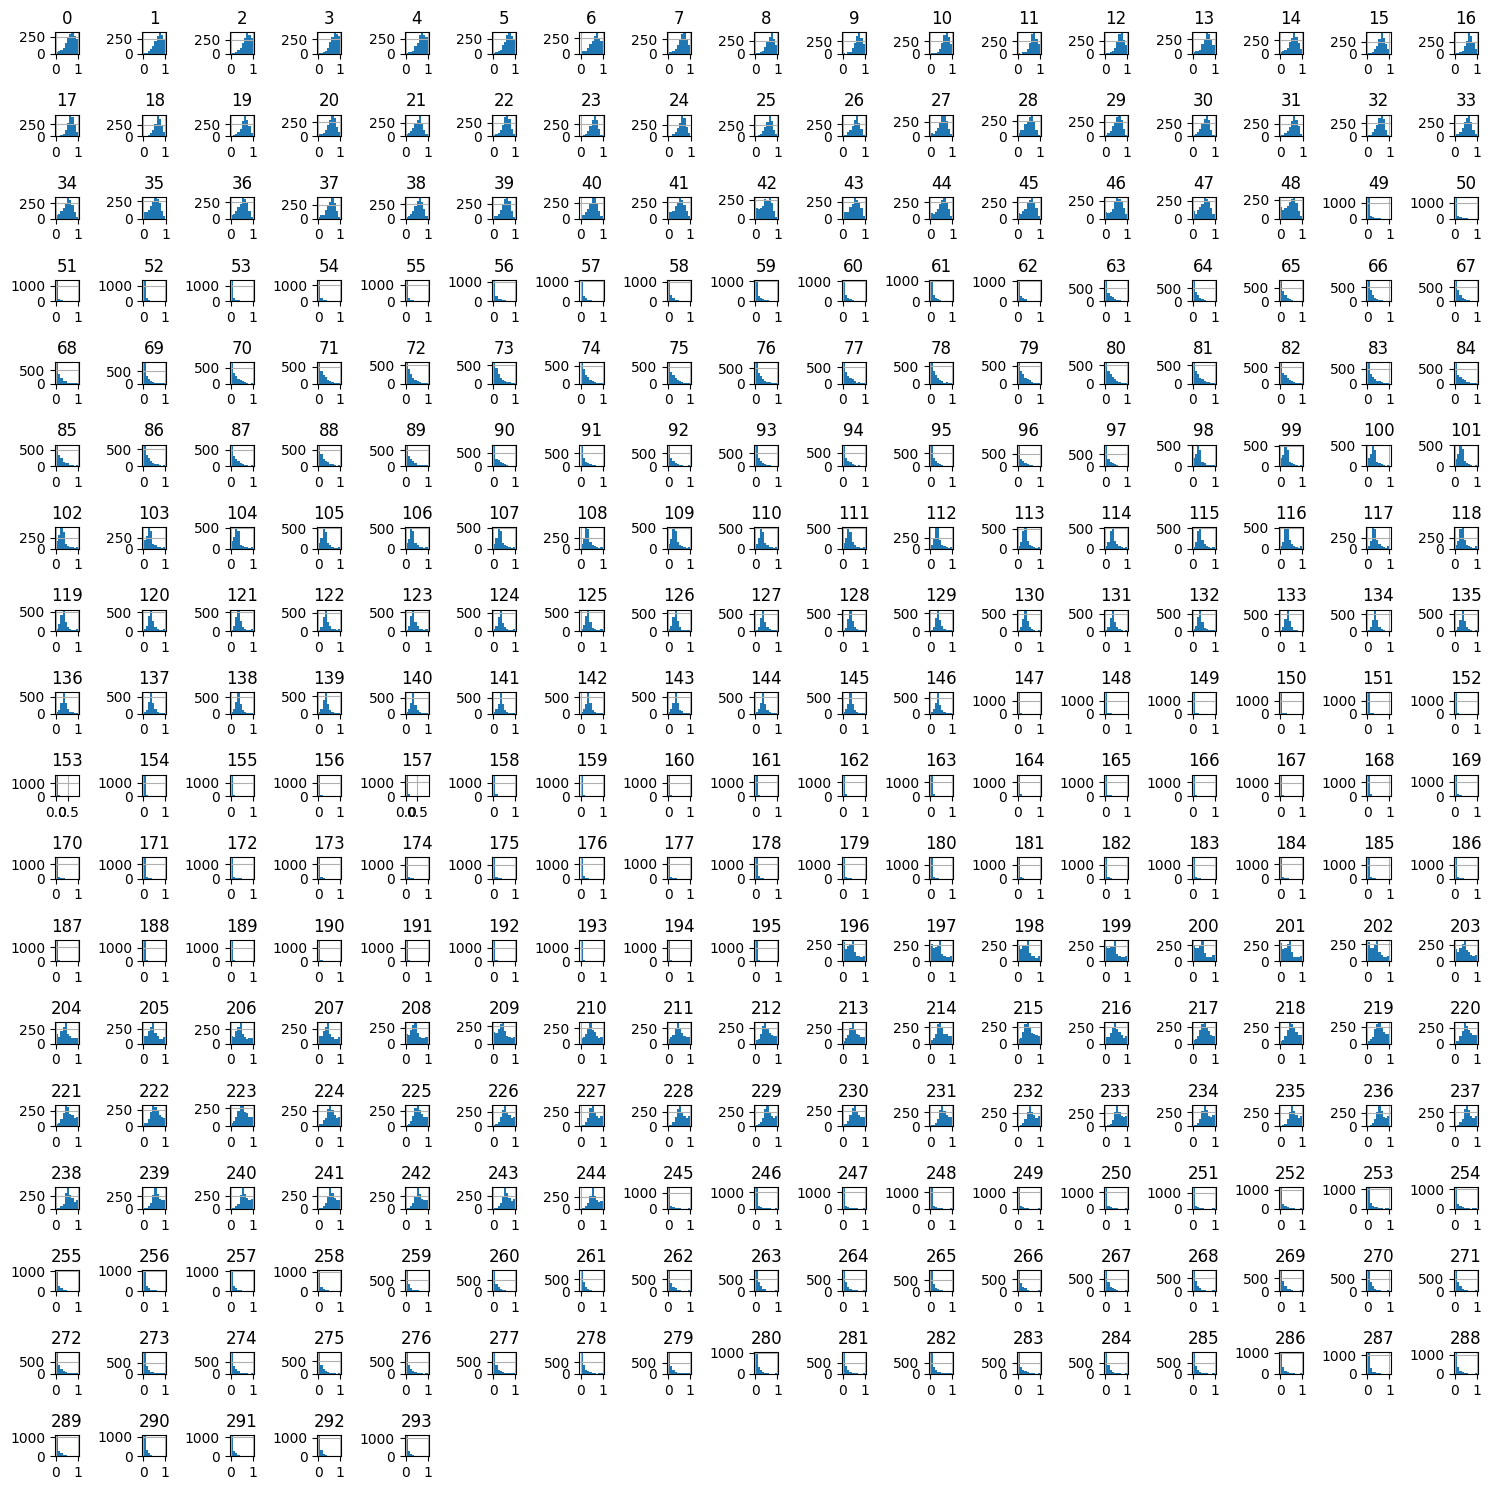

In [4]:
pd.DataFrame(X_train).hist(figsize=(15, 15))
plt.tight_layout()
plt.show()

All 294 features look continuous, so SMOTE is applicable here.

## Set up the models

We compare 3 XGBoost pipelines: one trained on the raw, imbalanced data, one trained after Random Over-Sampling (ROS), and one trained after SMOTE. Wrapping the resampler in an imbalanced-learn `Pipeline` ensures it only runs on the training fold, never on the data we evaluate on.

In [5]:
models = {
    "raw": None,
    "ros": RandomOverSampler(random_state=0),
    "smote": SMOTE(random_state=0),
}

pipelines = {
    name: Pipeline(
        ([("sampler", sampler)] if sampler else [])
        + [("model", XGBClassifier(
            random_state=0,
            eval_metric="logloss",
            n_jobs=-1,
        ))]
    )
    for name, sampler in models.items()
}

## Evaluate with cross-validation

For each pipeline we run 5-fold cross-validation on the training set. On every fold we record:

- ROC-AUC, which does not depend on a threshold
- F1-score at the default 0.5 threshold
- F1-score at the threshold that maximises it, found with a grid search on the validation fold

Cross-validation gives us the variability of these metrics across folds, not just a single point estimate.

In [6]:
thresholds = np.linspace(0.01, 0.99, 50)

def cv_scores(pipeline, X, y, cv):
    roc, f1_05, f1_best, best_thr = [], [], [], []

    for train_idx, val_idx in cv.split(X, y):
        pipeline.fit(X[train_idx], y[train_idx])
        proba = pipeline.predict_proba(X[val_idx])[:, 1]
        y_val = y[val_idx]

        roc.append(roc_auc_score(y_val, proba))
        f1_05.append(f1_score(y_val, proba >= 0.5))

        f1_grid = [f1_score(y_val, proba >= t) for t in thresholds]
        f1_best.append(max(f1_grid))
        best_thr.append(thresholds[np.argmax(f1_grid)])

    return np.array(roc), np.array(f1_05), np.array(f1_best), np.array(best_thr)

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

scores = {
    name: cv_scores(pipe, X_train, y_train, cv)
    for name, pipe in pipelines.items()
}

## Compare the results

### During cross-validation

In [8]:
rows = {}

for name, (roc, f1_default, f1_best, threshold) in scores.items():
    rows[name] = {
        "roc_auc": roc.mean(),
        "roc_auc_std": roc.std(),
        "f1_at_0.5": f1_default.mean(),
        "f1_at_0.5_std": f1_default.std(),
        "f1_best_threshold": f1_best.mean(),
        "f1_best_threshold_std": f1_best.std(),
        "best_threshold": threshold.mean(),
    }

results = pd.DataFrame.from_dict(rows, orient="index")

results.round(3)

,roc_auc,roc_auc_std,f1_at_0.5,f1_at_0.5_std,f1_best_threshold,f1_best_threshold_std,best_threshold
raw,0.787,0.042,0.071,0.063,0.311,0.020,0.062
ros,0.782,0.032,0.180,0.104,0.348,0.014,0.042
smote,0.766,0.052,0.241,0.037,0.318,0.059,0.166


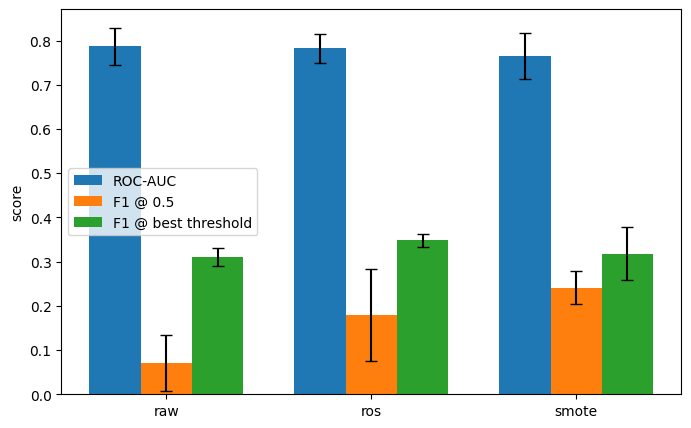

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(results))
width = 0.25

ax.bar(x - width, results["roc_auc"], width,
       yerr=results["roc_auc_std"], capsize=4, label="ROC-AUC")
ax.bar(x, results["f1_at_0.5"], width,
       yerr=results["f1_at_0.5_std"], capsize=4, label="F1 @ 0.5")
ax.bar(x + width, results["f1_best_threshold"], width,
       yerr=results["f1_best_threshold_std"], capsize=4, label="F1 @ best threshold")

ax.set_xticks(x)
ax.set_xticklabels(results.index)
ax.set_ylabel("score")
ax.legend()
outputdir="../../mlid-book/resources/ch6/ch6-demo.png"
plt.savefig(outputdir, dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

At the default 0.5 threshold, ROS and SMOTE look like a big improvement in F1-score over the raw model. ROC-AUC, which ignores the threshold entirely, is basically the same for all three. Let's visualise this.

### On the test set

In [10]:
test_results = {}

for name, pipeline in pipelines.items():
    threshold = scores[name][3].mean()

    pipeline.fit(X_train, y_train)
    proba = pipeline.predict_proba(X_test)[:, 1]

    test_results[name] = {
        "roc_auc": roc_auc_score(y_test, proba),
        "f1_at_0.5": f1_score(y_test, proba >= 0.5),
        "f1_at_cv_threshold": f1_score(y_test, proba >= threshold),
        "cv_threshold": threshold,
    }

test_results = pd.DataFrame.from_dict(test_results, orient="index")
test_results.round(3)

,roc_auc,f1_at_0.5,f1_at_cv_threshold,cv_threshold
raw,0.779,0.169,0.277,0.062
ros,0.790,0.194,0.325,0.042
smote,0.797,0.273,0.331,0.166


## Conclusion

- ROC-AUC is virtually unchanged between the raw model and its ROS / SMOTE counterparts: oversampling does not make the model better at ranking observations.
- At the default 0.5 threshold, ROS and SMOTE look far better on F1-score than the raw model.
- That gap collapses once every model is allowed to pick its own optimal threshold, and the best thresholds found for ROS and SMOTE are, like the raw model's, well below 0.5.

The F1-score "improvement" attributed to SMOTE is, in this case, a threshold artifact: oversampling moves the model's predicted probabilities closer to 0.5, so the default cut-off happens to work better. The raw model reaches a comparable F1-score by simply choosing a lower threshold — no synthetic data required.